In [43]:
import os
import pandas as pd
import numpy as np

In [45]:
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

IMAGES_DIR = os.path.join(PROJECT_PATH, "Data", "Images")
METADATA_DIR = os.path.join(PROJECT_PATH, "Data", "Metadata")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Images directory:", IMAGES_DIR)
print("Metadata directory:", METADATA_DIR)

Images directory: C:\Users\abc\projects\Cancer Cell Classification Project\Data\Images
Metadata directory: C:\Users\abc\projects\Cancer Cell Classification Project\Data\Metadata


In [49]:
image_folders = [
    f for f in os.listdir(IMAGES_DIR)
    if f.startswith("BBBC021_v1_images") and os.path.isdir(os.path.join(IMAGES_DIR, f))
]

print("Detected plates:")
for f in image_folders:
    print(f)

print("\nTotal plates:", len(image_folders))

Detected plates:
BBBC021_v1_images_Week1_22361
BBBC021_v1_images_Week1_22381
BBBC021_v1_images_Week2_24121
BBBC021_v1_images_Week3_25421
BBBC021_v1_images_Week3_25441
BBBC021_v1_images_Week3_25461
BBBC021_v1_images_Week3_25681
BBBC021_v1_images_Week3_25701
BBBC021_v1_images_Week3_25721
BBBC021_v1_images_Week4_27801
BBBC021_v1_images_Week4_27821
BBBC021_v1_images_Week4_27861
BBBC021_v1_images_Week5_28921
BBBC021_v1_images_Week5_29301
BBBC021_v1_images_Week5_29341

Total plates: 15


In [51]:
image_metadata_path = os.path.join(METADATA_DIR, "BBBC021_v1_image.csv")
moa_metadata_path = os.path.join(METADATA_DIR, "BBBC021_v1_moa.csv")

img_df = pd.read_csv(image_metadata_path)
moa_df = pd.read_csv(moa_metadata_path)

print("Image metadata shape:", img_df.shape)
print("MoA metadata shape:", moa_df.shape)

Image metadata shape: (13200, 13)
MoA metadata shape: (104, 3)


In [53]:
selected_plates = [
    folder.replace("BBBC021_v1_images_", "")
    for folder in image_folders
]

print("Selected plates:")
for p in selected_plates:
    print(p)

Selected plates:
Week1_22361
Week1_22381
Week2_24121
Week3_25421
Week3_25441
Week3_25461
Week3_25681
Week3_25701
Week3_25721
Week4_27801
Week4_27821
Week4_27861
Week5_28921
Week5_29301
Week5_29341


In [55]:
plate_df = img_df[img_df["Image_Metadata_Plate_DAPI"].isin(selected_plates)].copy()

print("Images in selected plates:", plate_df.shape[0])

Images in selected plates: 3600


In [57]:
merged_df = plate_df.merge(
    moa_df,
    left_on=["Image_Metadata_Compound", "Image_Metadata_Concentration"],
    right_on=["compound", "concentration"],
    how="inner"
)

print("Matched labelled samples:", merged_df.shape[0])

Matched labelled samples: 1264


In [59]:
merged_df = merged_df[merged_df["moa"] != "DMSO"].copy()

print("After removing DMSO:", merged_df.shape[0])

After removing DMSO: 904


In [61]:
target_classes = [
    "Microtubule stabilizers",
    "Microtubule destabilizers",
    "DNA damage",
    "Eg5 inhibitors",
    "Aurora kinase inhibitors"
]

dataset_df = merged_df[merged_df["moa"].isin(target_classes)].copy()

print("Final dataset size:", dataset_df.shape[0])
print("\nClass distribution:")
print(dataset_df["moa"].value_counts())

Final dataset size: 788

Class distribution:
moa
Microtubule stabilizers      384
Microtubule destabilizers    140
DNA damage                   108
Eg5 inhibitors                84
Aurora kinase inhibitors      72
Name: count, dtype: int64


In [67]:
dataset_df["DAPI_path"] = dataset_df.apply(
    lambda row: os.path.join(
        IMAGES_DIR,
        f"BBBC021_v1_images_{row['Image_Metadata_Plate_DAPI']}",
        row["Image_Metadata_Plate_DAPI"],
        row["Image_FileName_DAPI"]
    ),
    axis=1
)

dataset_df["Tubulin_path"] = dataset_df.apply(
    lambda row: os.path.join(
        IMAGES_DIR,
        f"BBBC021_v1_images_{row['Image_Metadata_Plate_DAPI']}",
        row["Image_Metadata_Plate_DAPI"],
        row["Image_FileName_Tubulin"]
    ),
    axis=1
)

dataset_df["Actin_path"] = dataset_df.apply(
    lambda row: os.path.join(
        IMAGES_DIR,
        f"BBBC021_v1_images_{row['Image_Metadata_Plate_DAPI']}",
        row["Image_Metadata_Plate_DAPI"],
        row["Image_FileName_Actin"]
    ),
    axis=1
)

dataset_df[["DAPI_path", "Tubulin_path", "Actin_path"]].head()

,DAPI_path,Tubulin_path,Actin_path
20,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...
21,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...
22,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...
23,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...
24,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...,C:\Users\abc\projects\Cancer Cell Classificati...


In [69]:
for col in ["DAPI_path", "Tubulin_path", "Actin_path"]:
    missing = (~dataset_df[col].apply(os.path.exists)).sum()
    print(f"{col}: missing {missing} / {len(dataset_df)}")

DAPI_path: missing 0 / 788
Tubulin_path: missing 0 / 788
Actin_path: missing 0 / 788


In [71]:
save_path = os.path.join(PROJECT_PATH, "Data", "expanded_dataset.csv")

dataset_df.to_csv(save_path, index=False)

print("Dataset saved:", save_path)
print("Total samples:", dataset_df.shape[0])

Dataset saved: C:\Users\abc\projects\Cancer Cell Classification Project\Data\expanded_dataset.csv
Total samples: 788


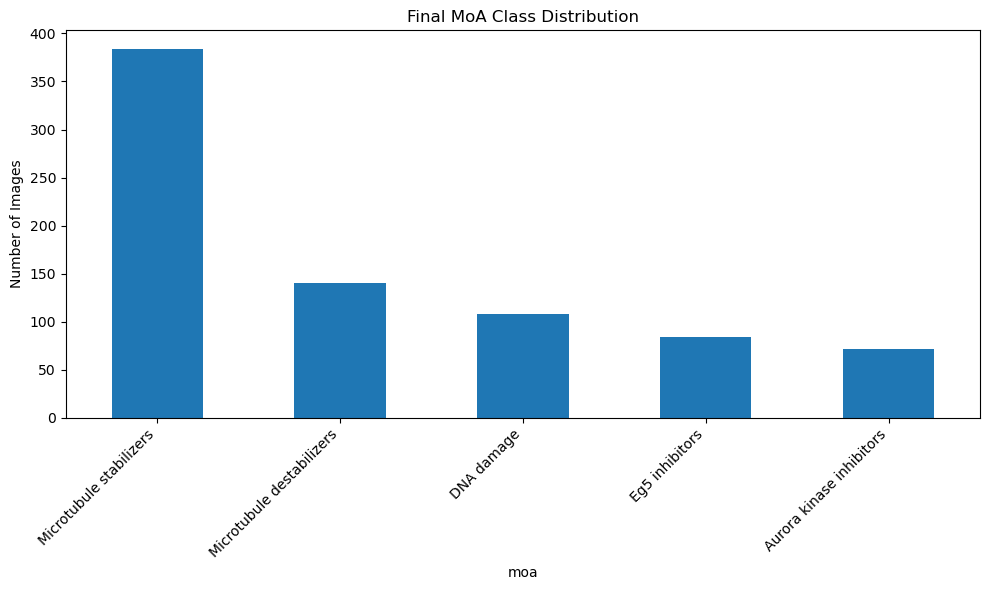

Figure saved: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\final_moa_class_distribution.png


In [73]:
import matplotlib.pyplot as plt

class_counts = dataset_df["moa"].value_counts()

plt.figure(figsize=(10, 6))
class_counts.plot(kind="bar")
plt.title("Final MoA Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "final_moa_class_distribution.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", fig_path)